<a href="https://colab.research.google.com/github/JorgeMarquezPiedra/Afluencia-RTP-Ciudad-de-Mexico-2022-a-2026-Python/blob/main/Afluencia_RTP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cargar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [ ]:
# Leer dataset
rtp = pd.read_csv('afluenciartp_desglosado_01_2026.csv', encoding='latin1')
rtp

,fecha,mes,anio,servicio,tipo_pago,afluencia
0,2022-01-01,Enero,2022.0,Servicios Temporales,Boleto,0.0
1,2022-01-01,Enero,2022.0,Servicios Temporales,Prepago,0.0
2,2022-01-01,Enero,2022.0,Servicios Temporales,Gratuidad,0.0
3,2022-01-01,Enero,2022.0,Atenea,Boleto,2702.0
4,2022-01-01,Enero,2022.0,Atenea,Prepago,0.0
...,...,...,...,...,...,...
36838,NaN,NaN,NaN,NaN,Prepago,NaN
36839,NaN,NaN,NaN,NaN,Gratuidad,NaN
36840,NaN,NaN,NaN,NaN,Boleto,NaN
36841,NaN,NaN,NaN,NaN,Prepago,NaN


In [ ]:
# Información del dataset
rtp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36843 entries, 0 to 36842
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   fecha      36819 non-null  object 
 1   mes        36819 non-null  object 
 2   anio       36819 non-null  float64
 3   servicio   36819 non-null  object 
 4   tipo_pago  36843 non-null  object 
 5   afluencia  36632 non-null  float64
dtypes: float64(2), object(4)
memory usage: 1.7+ MB


In [ ]:
# Pasar fecha a formato datetime
rtp['fecha'] = pd.to_datetime(rtp['fecha'])
rtp

,fecha,mes,anio,servicio,tipo_pago,afluencia
0,2022-01-01,Enero,2022.0,Servicios Temporales,Boleto,0.0
1,2022-01-01,Enero,2022.0,Servicios Temporales,Prepago,0.0
2,2022-01-01,Enero,2022.0,Servicios Temporales,Gratuidad,0.0
3,2022-01-01,Enero,2022.0,Atenea,Boleto,2702.0
4,2022-01-01,Enero,2022.0,Atenea,Prepago,0.0
...,...,...,...,...,...,...
36838,NaT,NaN,NaN,NaN,Prepago,NaN
36839,NaT,NaN,NaN,NaN,Gratuidad,NaN
36840,NaT,NaN,NaN,NaN,Boleto,NaN
36841,NaT,NaN,NaN,NaN,Prepago,NaN


In [ ]:
# Generar columna de dia
dia_mapping = {
    1: 'Lunes',
    2: 'Martes',
    3: 'Miércoles',
    4: 'Jueves',
    5: 'Viernes',
    6: 'Sábado',
    7: 'Domingo'
}

rtp['dia'] = rtp['fecha'].dt.dayofweek.map(dia_mapping)
rtp

,fecha,mes,anio,servicio,tipo_pago,afluencia,dia
0,2022-01-01,Enero,2022.0,Servicios Temporales,Boleto,0.0,Viernes
1,2022-01-01,Enero,2022.0,Servicios Temporales,Prepago,0.0,Viernes
2,2022-01-01,Enero,2022.0,Servicios Temporales,Gratuidad,0.0,Viernes
3,2022-01-01,Enero,2022.0,Atenea,Boleto,2702.0,Viernes
4,2022-01-01,Enero,2022.0,Atenea,Prepago,0.0,Viernes
...,...,...,...,...,...,...,...
36838,NaT,NaN,NaN,NaN,Prepago,NaN,NaN
36839,NaT,NaN,NaN,NaN,Gratuidad,NaN,NaN
36840,NaT,NaN,NaN,NaN,Boleto,NaN,NaN
36841,NaT,NaN,NaN,NaN,Prepago,NaN,NaN


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

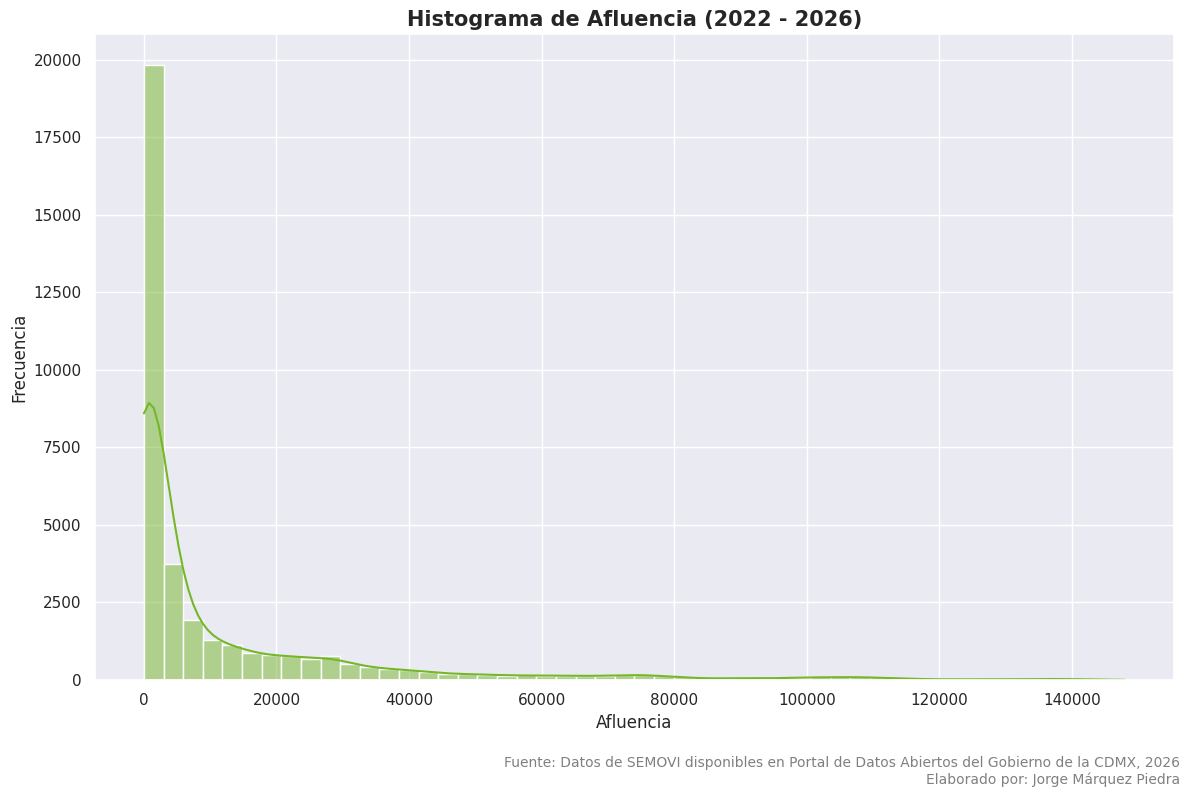

In [ ]:
# Histograma de afluencia
plt.figure(figsize=(12, 8))
sns.set_theme()
sns.histplot(data = rtp, x = 'afluencia', bins = 50, color = '#76b729', kde = True)
plt.title('Histograma de Afluencia (2022 - 2026)', fontsize = 15, fontweight = 'bold')
plt.xlabel('Afluencia')
plt.ylabel('Frecuencia')
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.14)
plt.savefig('histograma_afluencia.png')
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

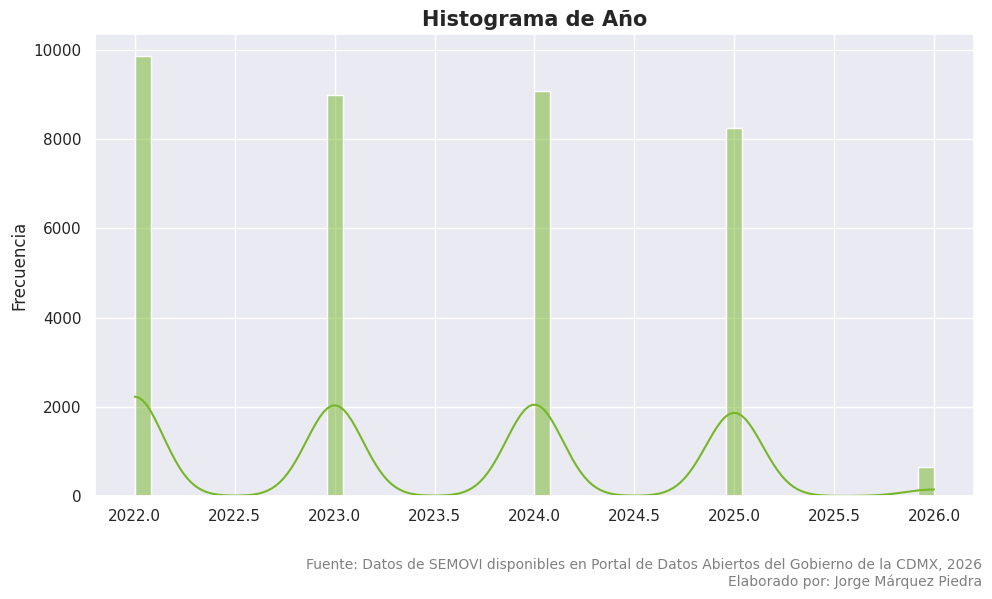

In [ ]:
# Histograma de años
plt.figure(figsize=(10, 6))
sns.set_theme()
sns.histplot(data = rtp, x = 'anio', bins = 50, color = '#76b729', kde = True)
plt.title('Histograma de Año', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel('Frecuencia')
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.16)
plt.savefig('histograma_año.png')
plt

In [ ]:
# Valores únicos en fecha, mes y anio
rtp['fecha'].unique()

<DatetimeArray>
['2022-01-01 00:00:00', '2022-01-02 00:00:00', '2022-01-03 00:00:00',
 '2022-01-04 00:00:00', '2022-01-05 00:00:00', '2022-01-06 00:00:00',
 '2022-01-07 00:00:00', '2022-01-08 00:00:00', '2022-01-09 00:00:00',
 '2022-01-10 00:00:00',
 ...
 '2026-01-23 00:00:00', '2026-01-24 00:00:00', '2026-01-25 00:00:00',
 '2026-01-26 00:00:00', '2026-01-27 00:00:00', '2026-01-28 00:00:00',
 '2026-01-29 00:00:00', '2026-01-30 00:00:00', '2026-01-31 00:00:00',
                 'NaT']
Length: 1493, dtype: datetime64[ns]

In [ ]:
rtp['mes'].unique()

array(['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio',
       'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre', nan],
      dtype=object)

In [ ]:
rtp['anio'].unique()

array([2022., 2023., 2024., 2025., 2026.,   nan])

In [ ]:
# Eliminar registros con NaT de fecha
drop_indices = rtp[rtp['fecha'].isna()].index
rtp = rtp.drop(drop_indices)
rtp

,fecha,mes,anio,servicio,tipo_pago,afluencia,dia
0,2022-01-01,Enero,2022.0,Servicios Temporales,Boleto,0.0,Viernes
1,2022-01-01,Enero,2022.0,Servicios Temporales,Prepago,0.0,Viernes
2,2022-01-01,Enero,2022.0,Servicios Temporales,Gratuidad,0.0,Viernes
3,2022-01-01,Enero,2022.0,Atenea,Boleto,2702.0,Viernes
4,2022-01-01,Enero,2022.0,Atenea,Prepago,0.0,Viernes
...,...,...,...,...,...,...,...
36814,2026-01-31,Enero,2026.0,ORDINARIO,Prepago,50562.0,Viernes
36815,2026-01-31,Enero,2026.0,ORDINARIO,Gratuidad,13985.0,Viernes
36816,2026-01-31,Enero,2026.0,SERVICIOS TEMPORALES,Boleto,0.0,Viernes
36817,2026-01-31,Enero,2026.0,SERVICIOS TEMPORALES,Prepago,1177.0,Viernes


In [ ]:
rtp['mes'].unique()

array(['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio',
       'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre'],
      dtype=object)

In [ ]:
rtp['anio'].unique()

array([2022., 2023., 2024., 2025., 2026.])

In [ ]:
# Pasar valores de anio a Int
rtp['anio'] = rtp['anio'].astype(int)
rtp

,fecha,mes,anio,servicio,tipo_pago,afluencia,dia
0,2022-01-01,Enero,2022,Servicios Temporales,Boleto,0.0,Viernes
1,2022-01-01,Enero,2022,Servicios Temporales,Prepago,0.0,Viernes
2,2022-01-01,Enero,2022,Servicios Temporales,Gratuidad,0.0,Viernes
3,2022-01-01,Enero,2022,Atenea,Boleto,2702.0,Viernes
4,2022-01-01,Enero,2022,Atenea,Prepago,0.0,Viernes
...,...,...,...,...,...,...,...
36814,2026-01-31,Enero,2026,ORDINARIO,Prepago,50562.0,Viernes
36815,2026-01-31,Enero,2026,ORDINARIO,Gratuidad,13985.0,Viernes
36816,2026-01-31,Enero,2026,SERVICIOS TEMPORALES,Boleto,0.0,Viernes
36817,2026-01-31,Enero,2026,SERVICIOS TEMPORALES,Prepago,1177.0,Viernes


In [ ]:
# Valores únicos en servicios
rtp['servicio'].unique()

array(['Servicios Temporales', 'Atenea', 'Ecoatenea', 'EcobÃºs',
       'Expdirecto', 'Expreso', 'NochebÃºs', 'Ordinario', 'S/Metro',
       'Apoyo Metro L1', 'Circuito Hospitales', 'Expreso Directo',
       'Circuito Hospitales $8.00', 'Apoyo Concesionado',
       'Apoyo concesionado', 'ATENEA', 'ECOBÚS', 'EXPRESO', 'NOCHEBÚS',
       'ORDINARIO', 'S/METRO', 'EXPDIRECTO', 'CIRCUITO HOSPITALES',
       'SERVICIOS TEMPORALES', 'APOYO A CONCESIONADO', 'ECOBÃ\x9aS',
       'NOCHEBÃ\x9aS', 'ECOBUS', 'NOCHEBUS', 'ATENEA '], dtype=object)

In [ ]:
# Mapeo de correción de valores en servicio
servicio_mapping = {
    'Ecoatenea': 'Eco Atenea',
    'EcobÃºs': 'Ecobús',
    'Expdirecto': 'Expreso Directo',
    'NochebÃºs': 'Nochebús',
    'S/Metro': 'Apoyo Metro',
    'Apoyo Metro L1': 'Apoyo Metro',
    'Circuito Hospitales $8.00': 'Circuito Hospitales',
    'Apoyo concesionado': 'Apoyo Concesionado',
    'ATENEA': 'Atenea',
    'ECOBÚS': 'Ecobús',
    'EXPRESO': 'Expreso',
    'NOCHEBÚS': 'Nochebús',
    'ORDINARIO': 'Ordinario',
    'S/METRO': 'Apoyo Metro',
    'EXPDIRECTO': 'Expreso Directo',
    'CIRCUITO HOSPITALES': 'Circuito Hospitales',
    'SERVICIOS TEMPORALES': 'Servicios Temporales',
    'APOYO A CONCESIONADO': 'Apoyo Concesionado',
    'ECOBÃ\x9aS': 'Ecobús',
    'NOCHEBÃ\x9aS': 'Nochebús',
    'ECOBUS': 'Ecobús',
    'NOCHEBUS': 'Nochebús',
    'ATENEA ': 'Atenea'
}

# Aplica el mapeo y luego rellena los NaN con los valores originales de la columna 'servicio'
rtp['servicio'] = rtp['servicio'].map(servicio_mapping).fillna(rtp['servicio'])
rtp['servicio'].unique()

array(['Servicios Temporales', 'Atenea', 'Eco Atenea', 'Ecobús',
       'Expreso Directo', 'Expreso', 'Nochebús', 'Ordinario',
       'Apoyo Metro', 'Circuito Hospitales', 'Apoyo Concesionado'],
      dtype=object)

In [ ]:
rtp

,fecha,mes,anio,servicio,tipo_pago,afluencia,dia
0,2022-01-01,Enero,2022,Servicios Temporales,Boleto,0.0,Viernes
1,2022-01-01,Enero,2022,Servicios Temporales,Prepago,0.0,Viernes
2,2022-01-01,Enero,2022,Servicios Temporales,Gratuidad,0.0,Viernes
3,2022-01-01,Enero,2022,Atenea,Boleto,2702.0,Viernes
4,2022-01-01,Enero,2022,Atenea,Prepago,0.0,Viernes
...,...,...,...,...,...,...,...
36814,2026-01-31,Enero,2026,Ordinario,Prepago,50562.0,Viernes
36815,2026-01-31,Enero,2026,Ordinario,Gratuidad,13985.0,Viernes
36816,2026-01-31,Enero,2026,Servicios Temporales,Boleto,0.0,Viernes
36817,2026-01-31,Enero,2026,Servicios Temporales,Prepago,1177.0,Viernes


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

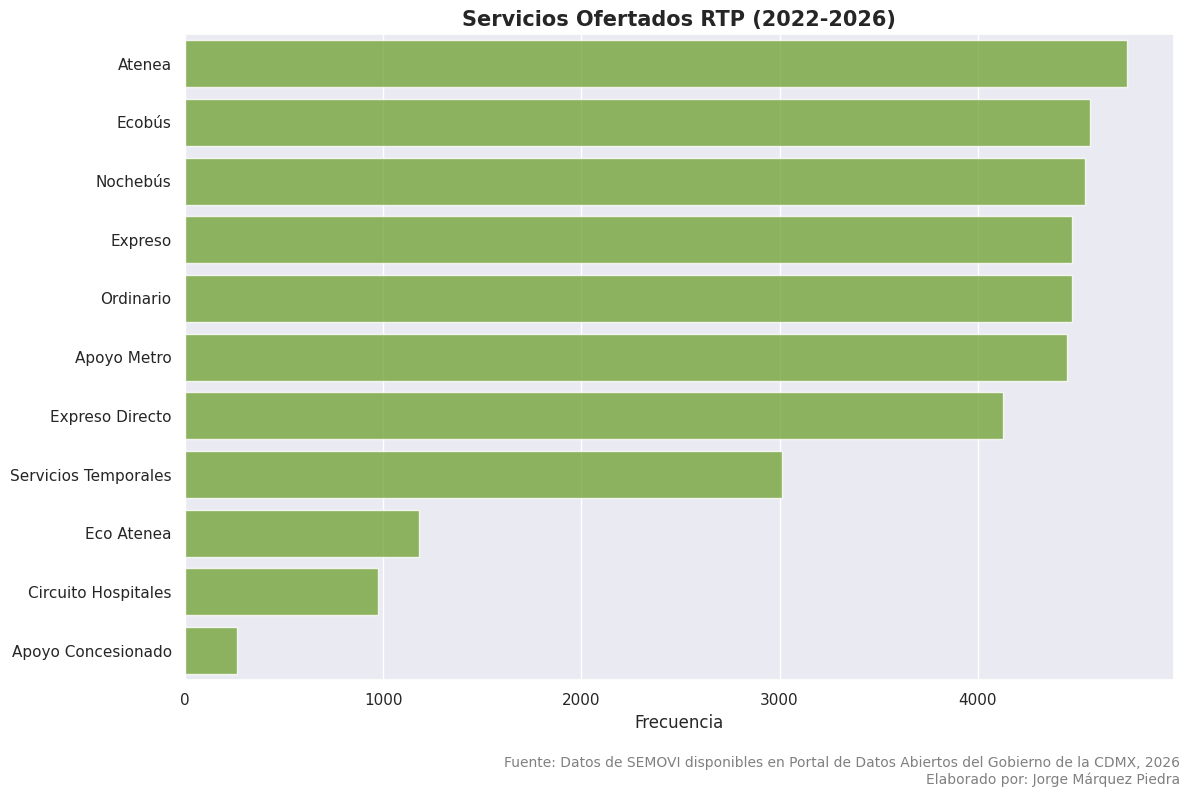

In [ ]:
# Countplot de servicio
plt.figure(figsize=(12, 8))
sns.set_theme()
sns.countplot(data = rtp, y = 'servicio', color = '#76b729', alpha = 0.8, order = rtp['servicio'].value_counts().index)
plt.title('Servicios Ofertados RTP (2022-2026)', fontsize = 15, fontweight = 'bold')
plt.xlabel('Frecuencia')
plt.ylabel(None)
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.14)
plt.savefig('countplot_servicios.png')
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

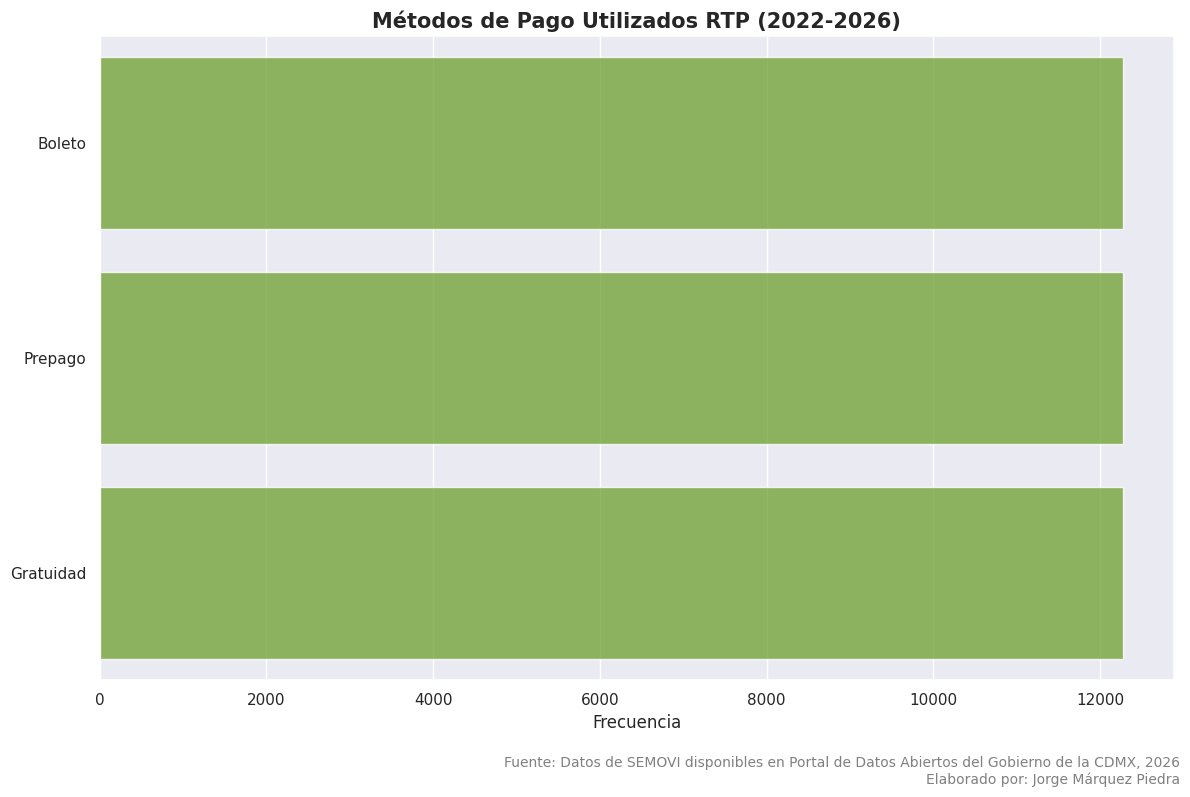

In [ ]:
# Countplot de métodos de pago
plt.figure(figsize=(12, 8))
sns.set_theme()
sns.countplot(data = rtp, y = 'tipo_pago', color = '#76b729', alpha = 0.8, order = rtp['tipo_pago'].value_counts().index)
plt.title('Métodos de Pago Utilizados RTP (2022-2026)', fontsize = 15, fontweight = 'bold')
plt.xlabel('Frecuencia')
plt.ylabel(None)
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.14)
plt.savefig('countplot_pago.png')
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

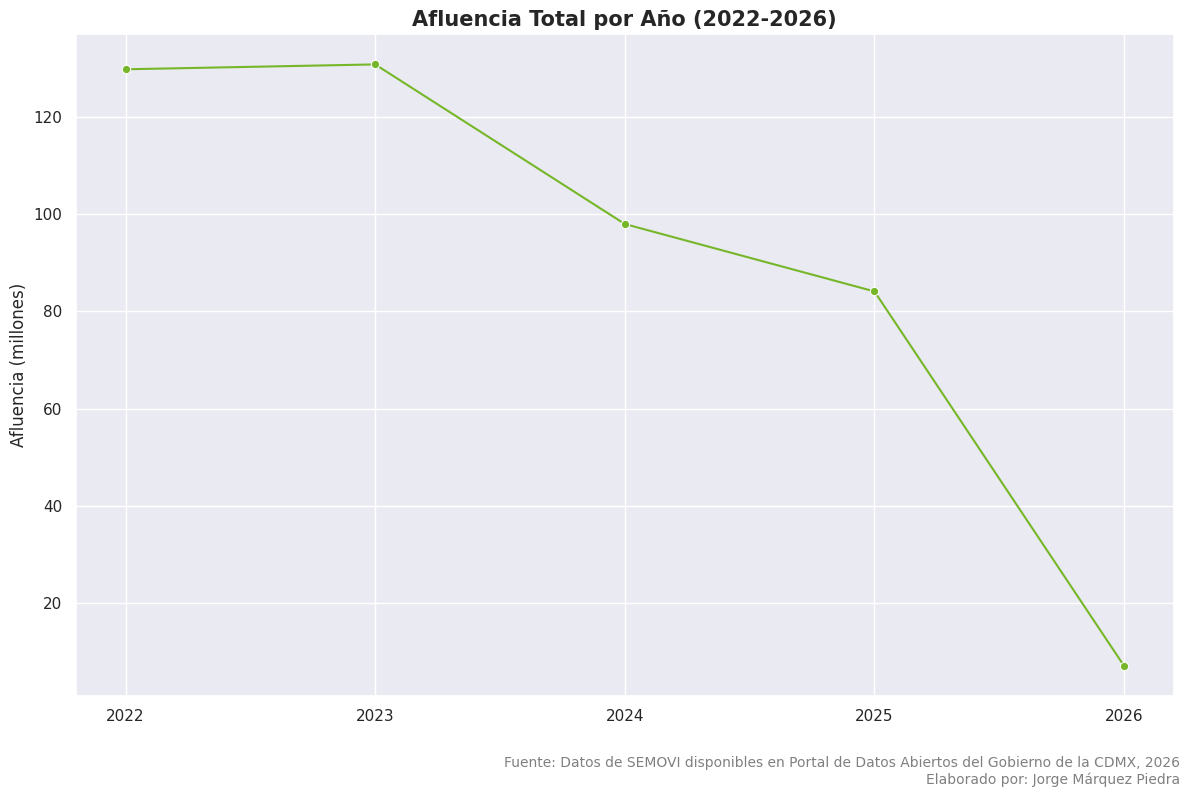

In [ ]:
# Afluencia por año
afluencia_por_anio = rtp.groupby('anio')['afluencia'].sum().reset_index()

# Convertir a millones
afluencia_por_anio['afluencia_millones'] = afluencia_por_anio['afluencia'] / 1_000_000

# Gráfico de línea de afluencia por año
plt.figure(figsize=(12, 8))
sns.lineplot(data = afluencia_por_anio, x = 'anio', y = 'afluencia_millones', marker = 'o', color = '#76b729')
plt.title('Afluencia Total por Año (2022-2026)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel('Afluencia (millones)')
plt.xticks(afluencia_por_anio['anio'].unique())
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('afluencia_total_por_año.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

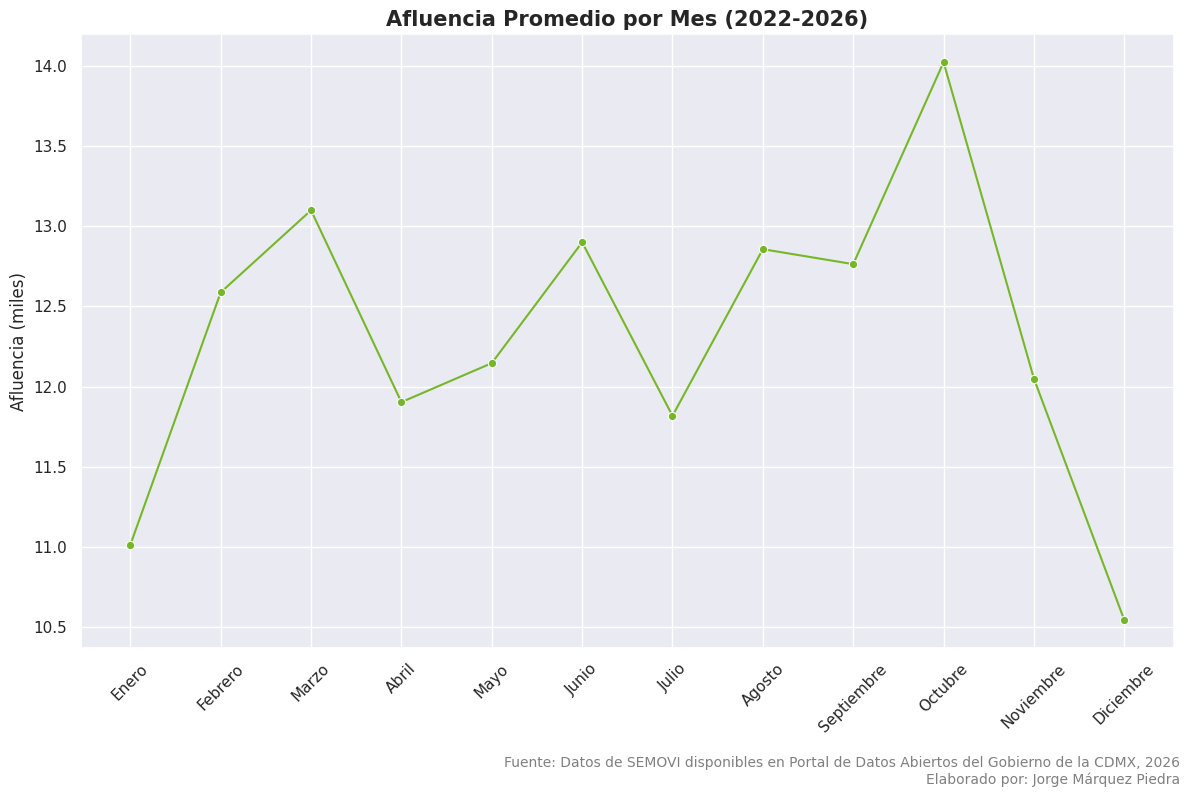

In [ ]:
# Afluencia por mes
afluencia_por_mes = rtp.groupby('mes')['afluencia'].mean().reset_index()

# Definir el orden correcto de meses
orden_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

# Ordenar el dataframe usando el orden de meses
afluencia_por_mes['mes'] = pd.Categorical(afluencia_por_mes['mes'], categories = orden_meses, ordered = True)
afluencia_por_mes = afluencia_por_mes.sort_values('mes')

# Convertir a miles
afluencia_por_mes['afluencia_miles'] = afluencia_por_mes['afluencia'] / 1_000

# Gráfico de línea de afluencia por año
plt.figure(figsize=(12, 8))
sns.lineplot(data = afluencia_por_mes, x = 'mes', y = 'afluencia_miles', marker = 'o', color = '#76b729')
plt.title('Afluencia Promedio por Mes (2022-2026)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel('Afluencia (miles)')
plt.xticks(rotation = 45)
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.18)
plt.savefig('afluencia_promedio_mes.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

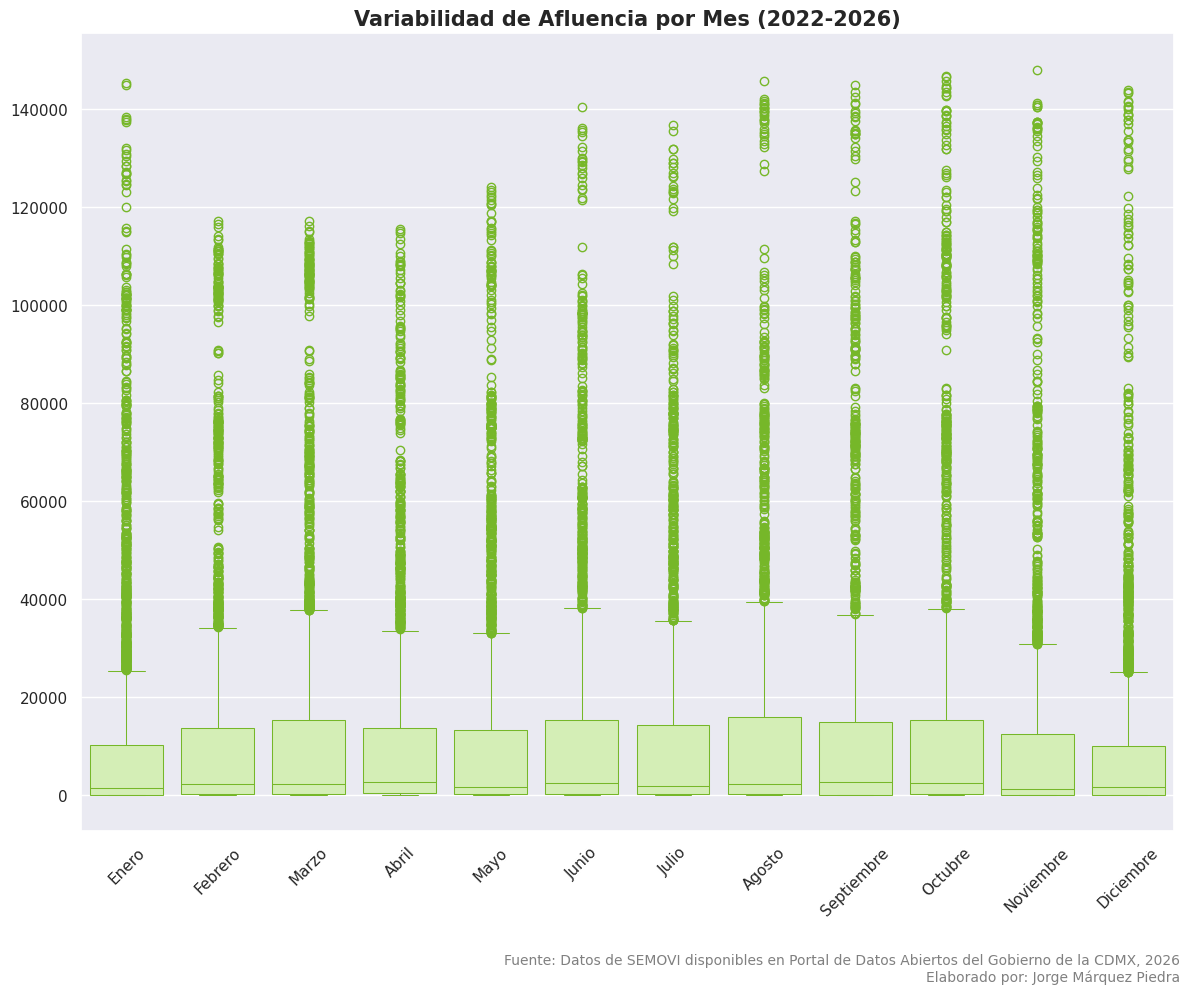

In [ ]:
# Boxplot de afluencia por estación
plt.figure(figsize=(12, 10))
sns.set_theme()
sns.boxplot(data = rtp, x = 'mes', y = 'afluencia', color = '#d5f7ad', linecolor = "#76b729", linewidth = 0.75)
plt.title('Variabilidad de Afluencia por Mes (2022-2026)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel(None)
plt.xticks(rotation = 45)
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.16)
plt.savefig('boxplot_por_mes.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

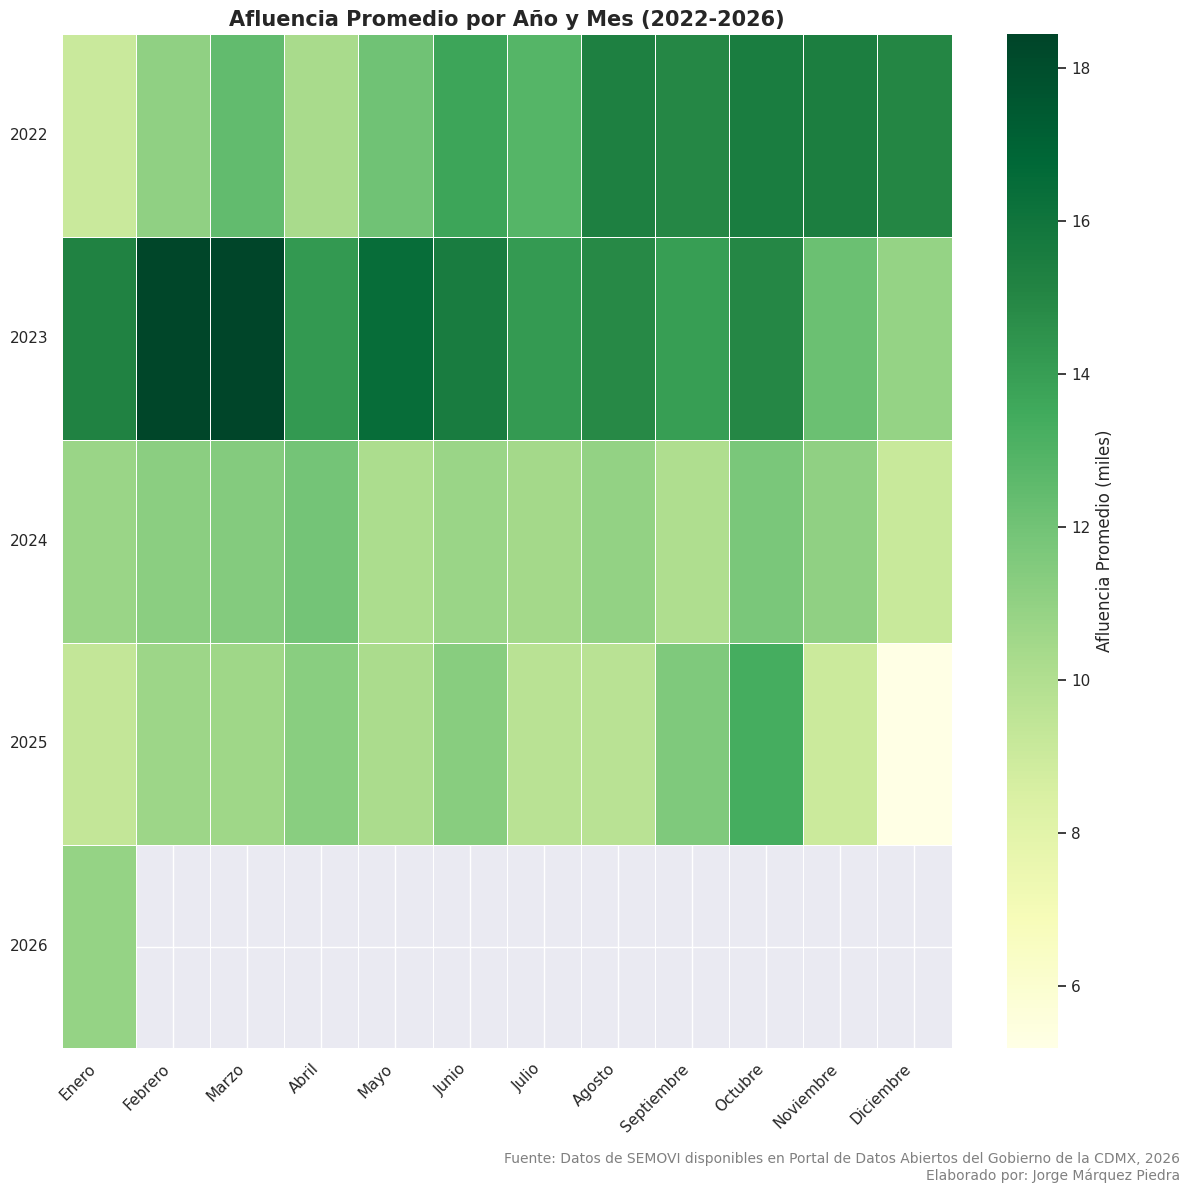

In [ ]:
pivot = rtp.pivot_table(values = 'afluencia', index = 'anio', columns = 'mes', aggfunc = 'mean')

# Convertir a miles
pivot = pivot / 1_000

# Ordenar los meses para el mapa
pivot = pivot[orden_meses]

plt.figure(figsize=(12, 12))
sns.set_theme()
sns.heatmap(pivot, cmap = "YlGn", fmt = ".0f", linewidths = .5, cbar_kws = {'label': 'Afluencia Promedio (miles)'})
plt.title('Afluencia Promedio por Año y Mes (2022-2026)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel(None)
plt.xticks(rotation = 45, ha = 'right')
plt.yticks(rotation = 0)
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('afluencia_heatmap_anio_mes.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

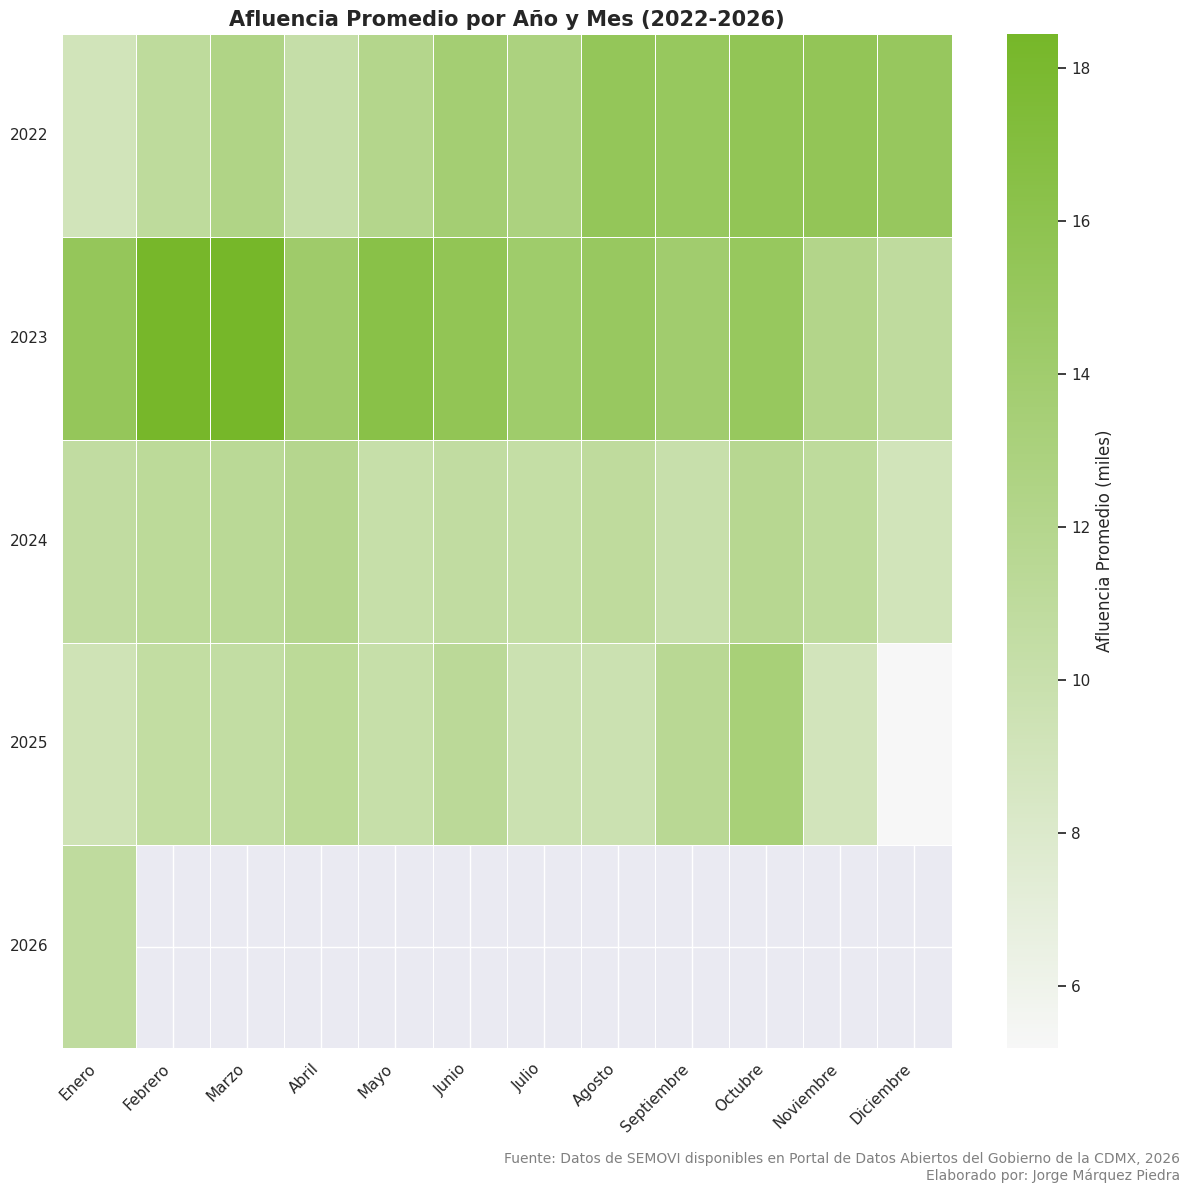

In [ ]:
# Heatmap con color personalizado
from matplotlib.colors import LinearSegmentedColormap

# Crear paleta personalizada para Tren Ligero
custom_rtp = LinearSegmentedColormap.from_list("rtp_palette", ["#f7f7f7", "#76b729"])

plt.figure(figsize=(12, 12))
sns.set_theme()
sns.heatmap(pivot, cmap = custom_rtp, fmt = ".0f", linewidths = .5, cbar_kws = {'label': 'Afluencia Promedio (miles)'})
plt.title('Afluencia Promedio por Año y Mes (2022-2026)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel(None)
plt.xticks(rotation = 45, ha = 'right')
plt.yticks(rotation = 0)
plt.figtext(0.99, 0.01, 'Fuente: Datos de SEMOVI disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('afluencia_heatmap_anio_mes_personalizado.png', dpi = 300)
plt